# TIME SERIES AND PHASE PORTRAIT OF THE COEXISTENCE EQUILIBRIUM


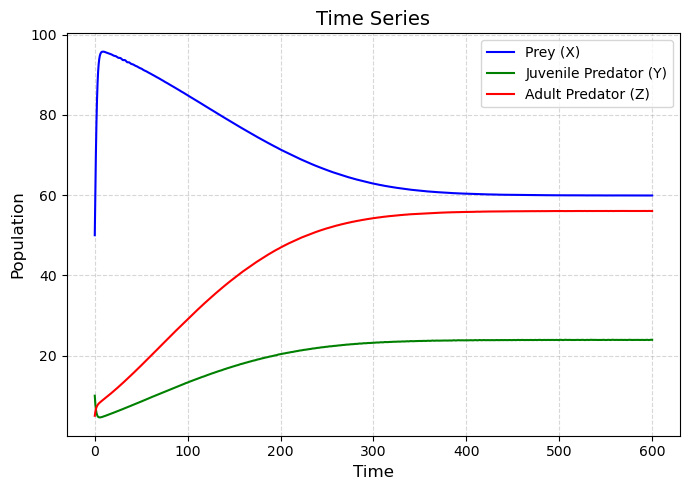

In [8]:
#TIME SERIES
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from mpl_toolkits.mplot3d import Axes3D


# Parameter 
r = 0.8     # laju pertumbuhan prey
K = 100     # kapasitas dukung(carriying capacity)
m1 = 0.4    # laju pemangsaan adult predator terhadap prey
n1 = 10     # Half-saturation constan untuk pemangsaan prey oleh adult predator
m2 = 0.2    # laju pemangsaan/kanibalisme predator dewasa terhadap predator muda
n2 = 5      ## Half-saturation constan untuk pemangsaan juvenile predator oleh adult predator
e1 = 0.2    # efisiensi energi dari pemangsaan prey menjadi boimassa predator dewasa
e2 = 0.15   # efisiensi energi dari pemangsaan predaator muda menjadi boimassa predator dewasa
b  = 0.4    # kelahiran predator muda
m  = 0.25   # pertumbuhan predator muda ke predator dewasa
d1 = 0.3    # kematian predator muda
d2 = 0.2    # kematian predator dewasa

# persamaan sistem diferensial

def fish_system(t, vars):
    X, Y, Z = vars
    dXdt = r*X*(1 - X/K) - (m1*X*Z)/(n1 + X)
    dYdt = b*Z - (m2*Y*Z)/(n2 + Y) - m*Y - d1*Y
    dZdt = e1*(m1*X*Z)/(n1 + X) + e2*(m2*Y*Z)/(n2 + Y) + m*Y - d2*Z
    return [dXdt, dYdt, dZdt]

# Kondisi awal & rentang waktu
y0 = [50, 10, 5]   # X0, Y0, Z0
t_span = (0, 600)
t_eval = np.linspace(*t_span, 1000)

# Simulasi numerik
sol = solve_ivp(fish_system, t_span, y0, t_eval=t_eval, method='RK45')

X, Y, Z = sol.y
t = sol.t

# Plot TIME SERIES
plt.figure(figsize=(7,5))
plt.plot(t, X, 'b-', label='Prey (x)')
plt.plot(t, Y, 'g-', label='Juvenile Predator (y)')
plt.plot(t, Z, 'r-', label='Adult Predator (z)')
plt.xlabel('Time', fontsize=12)
plt.ylabel('Population', fontsize=12)
plt.title('Time Series', fontsize=14)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


=== COEXISTENCE EQUILIBRIUM (E2) ===
x* = 59.907754
y* = 23.909174
z* = 56.055178



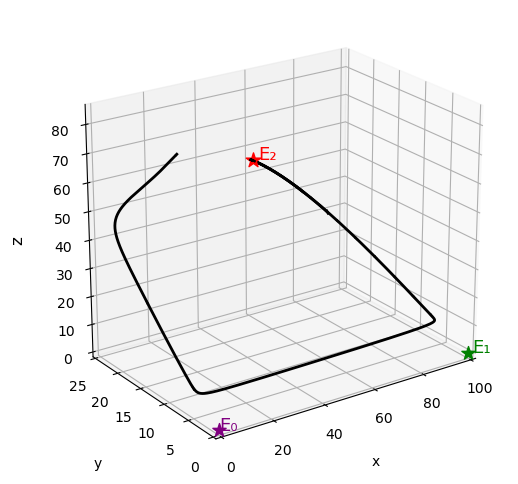

In [7]:
# MODEL – 3D PHASE PORTRAIT E2(x*,y*,z*)

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.optimize import fsolve
from mpl_toolkits.mplot3d import Axes3D

# Parameter
r = 0.8
K = 100
m1 = 0.4
n1 = 10
m2 = 0.2
n2 = 5
e1 = 0.2
e2 = 0.15
b  = 0.4
m  = 0.25
d1 = 0.3
d2 = 0.2

# Persamaan Sistem
def fish_system(t, vars):
    X, Y, Z = vars
    dXdt = r*X*(1 - X/K) - (m1*X*Z)/(n1 + X)
    dYdt = b*Z - (m2*Y*Z)/(n2 + Y) - m*Y - d1*Y
    dZdt = e1*(m1*X*Z)/(n1 + X) + e2*(m2*Y*Z)/(n2 + Y) + m*Y - d2*Z
    return [dXdt, dYdt, dZdt]

# Titik Kritis Interior 
def F(vars):
    return fish_system(0, vars)

guess = [100, 50, 80]
Xeq, Yeq, Zeq = fsolve(F, guess)

print("\n=== COEXISTENCE EQUILIBRIUM (E2) ===")
print(f"x* = {Xeq:.6f}")
print(f"y* = {Yeq:.6f}")
print(f"z* = {Zeq:.6f}")
print("=================================\n")

# Trajektori mendekati titik kritis
initial_conditions = [
    [Xeq*1.20, Yeq*0.80, Zeq*0.80],
    [Xeq*0.70, Yeq*1.40, Zeq*1.10],
    [Xeq*1.10, Yeq*1.10, Zeq*0.60]
]

t_span = (0, 600)
t_eval = np.linspace(8, 600, 6000)


# PLOT 3D PHASE PORTRAIT 
fig = plt.figure(figsize=(6,6))
ax = fig.add_subplot(111, projection='3d')

for y0 in initial_conditions:
    sol = solve_ivp(fish_system, t_span, y0, t_eval=t_eval, max_step=0.4)
    X, Y, Z = sol.y
    ax.plot(X, Y, Z, color='black', lw=2)


    for i in range(0, len(X)-1, 250):
        ax.quiver(
            X[i], Y[i], Z[i],
            X[i+1]-X[i], Y[i+1]-Y[i], Z[i+1]-Z[i],
            length=1.0, normalize=True, color='black'
        )

# titik equilibrium
ax.scatter(Xeq, Yeq, Zeq, color='red', s=120, marker='*')
ax.text(Xeq+2, Yeq, Zeq, "E₂", color='red', fontsize=13)

ax.scatter(K, 0, 0, color='green', s=100, marker='*')
ax.text(K+2, 0, 0, "E₁", color='green', fontsize=13)

ax.scatter(0, 0, 0, color='purple', s=100, marker='*')
ax.text(0, 0, 0, "E₀", color='purple', fontsize=13)


ax.set_xlabel("x", labelpad=12)
ax.set_ylabel("y", labelpad=14)


ax.text2D(
    -0.08, 0.5,
    "z",
    transform=ax.transAxes,
    rotation=90,
    fontsize=12,
    va='center'
)


ax.set_xlim(0, 100)
ax.set_ylim(0, 25)
ax.set_zlim(0, 85)

ax.set_box_aspect((1.4, 1.0, 1.2))
ax.view_init(elev=22, azim=235)


ax.grid(True, linestyle='--', alpha=0.8)

plt.show()